1. Install Required Packages

In [1]:
# Run this first!
!pip install matplotlib pandas seaborn numpy

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 2.9 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.1 MB 4.6 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.1 MB 5.7 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 7.4 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 8.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   --------- ------------------------------ 2.6/11.0 MB 12.9 MB/s eta 0:00:01
   ------------------- -------------------- 5.2/11.0 MB 12.8 MB/

2. Import Libraries and Setup

In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from pathlib import Path

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

print("✅ All libraries imported successfully!")
print(f"Current directory: {os.getcwd()}")

✅ All libraries imported successfully!
Current directory: c:\Users\Admin\Downloads\FYP\trained_model_task08_250epochs\content\nnunet_dirs\nnUNet_results\Dataset008_HepaticVessel\nnUNetTrainer__nnUNetPlans__3d_fullres\fold_0


3. Verify Files Exist

In [3]:
# Check if training log exists
log_file = "training_log_2025_10_20_15_44_11.txt"

if os.path.exists(log_file):
    file_size = os.path.getsize(log_file) / 1024
    print(f"✅ Training log found!")
    print(f"   File: {log_file}")
    print(f"   Size: {file_size:.2f} KB")
else:
    print(f"❌ Training log not found!")
    print(f"   Looking for: {log_file}")
    print(f"   Current files: {os.listdir('.')}")

✅ Training log found!
   File: training_log_2025_10_20_15_44_11.txt
   Size: 102.88 KB


4. Parse Training Log

In [6]:
print("📖 Parsing training log...")

# Initialize lists
epochs = []
train_losses = []
val_losses = []
dice_1_scores = []
dice_2_scores = []
learning_rates = []
epoch_times = []

# Read entire file
with open(log_file, 'r', encoding='utf-8') as f:
    content = f.read()

# Split into blocks by "Epoch " markers
lines = content.split('\n')

i = 0
while i < len(lines):
    line = lines[i]
    
    # Look for epoch start
    if 'Epoch ' in line and 'Current learning rate' not in line:
        epoch_match = re.search(r'Epoch (\d+)', line)
        if epoch_match:
            epoch_num = int(epoch_match.group(1))
            
            # Now look ahead in next ~10 lines for all the data
            temp_data = {'epoch': epoch_num}
            
            for j in range(i, min(i+15, len(lines))):
                check_line = lines[j]
                
                # Get learning rate
                if 'Current learning rate:' in check_line:
                    lr_match = re.search(r'Current learning rate: ([\d.]+)', check_line)
                    if lr_match:
                        temp_data['lr'] = float(lr_match.group(1))
                
                # Get train loss
                if 'train_loss' in check_line:
                    tl_match = re.search(r'train_loss ([-\d.]+)', check_line)
                    if tl_match:
                        temp_data['train_loss'] = float(tl_match.group(1))
                
                # Get val loss
                if 'val_loss' in check_line:
                    vl_match = re.search(r'val_loss ([-\d.]+)', check_line)
                    if vl_match:
                        temp_data['val_loss'] = float(vl_match.group(1))
                
                # Get dice scores
                if 'Pseudo dice' in check_line:
                    dice_match = re.search(r'np\.float32\(([\d.]+)\), np\.float32\(([\d.]+)\)', check_line)
                    if dice_match:
                        temp_data['dice_1'] = float(dice_match.group(1))
                        temp_data['dice_2'] = float(dice_match.group(2))
                
                # Get epoch time
                if 'Epoch time:' in check_line:
                    time_match = re.search(r'Epoch time: ([\d.]+) s', check_line)
                    if time_match:
                        temp_data['epoch_time'] = float(time_match.group(1))
            
            # Check if we got all the required data
            required_keys = ['epoch', 'lr', 'train_loss', 'val_loss', 'dice_1', 'dice_2', 'epoch_time']
            if all(key in temp_data for key in required_keys):
                epochs.append(temp_data['epoch'])
                learning_rates.append(temp_data['lr'])
                train_losses.append(temp_data['train_loss'])
                val_losses.append(temp_data['val_loss'])
                dice_1_scores.append(temp_data['dice_1'])
                dice_2_scores.append(temp_data['dice_2'])
                epoch_times.append(temp_data['epoch_time'])
    
    i += 1

# Create DataFrame
df = pd.DataFrame({
    'epoch': epochs,
    'train_loss': train_losses,
    'val_loss': val_losses,
    'dice_1': dice_1_scores,
    'dice_2': dice_2_scores,
    'learning_rate': learning_rates,
    'epoch_time': epoch_times
})

# Parse EMA dice improvements separately
ema_dice_list = []
for line in lines:
    if "New best EMA pseudo Dice:" in line:
        match = re.search(r'EMA pseudo Dice: ([\d.]+)', line)
        if match:
            ema_dice_list.append(float(match.group(1)))

print(f"✅ Parsing complete!")
print(f"   Total epochs parsed: {len(df)}")
if len(df) > 0:
    print(f"   Epochs range: {df['epoch'].min()} to {df['epoch'].max()}")
    print(f"   Best EMA Dice: {max(ema_dice_list) if ema_dice_list else 'N/A'}")
    print(f"   Model improvements: {len(ema_dice_list)} times")
    print(f"\n📊 First few rows:")
    print(df.head(10))
    print(f"\n📊 Last few rows:")
    print(df.tail(5))
    print(f"\n📊 Basic statistics:")
    print(df.describe())
else:
    print("❌ No epoch data was parsed. Let's check the file format...")
    print("\nFirst 50 lines of the log file:")
    with open(log_file, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i < 50:
                print(f"{i}: {line.rstrip()}")
            else:
                break

📖 Parsing training log...
✅ Parsing complete!
   Total epochs parsed: 270
   Epochs range: 0 to 270
   Best EMA Dice: 0.7378000020980835
   Model improvements: 81 times

📊 First few rows:
   epoch  train_loss  val_loss  dice_1  dice_2  learning_rate  epoch_time
0      0      0.0505   -0.0062  0.2838  0.0000        0.00999      196.66
1      1     -0.1074   -0.2192  0.4973  0.3289        0.00998      195.98
2      2     -0.1821   -0.2108  0.5568  0.2436        0.00997      196.22
3      3     -0.1818   -0.2204  0.5623  0.2943        0.00996      195.63
4      4     -0.2088   -0.2448  0.5535  0.3691        0.00995      195.51
5      5     -0.2226   -0.3269  0.5655  0.5165        0.00995      196.01
6      6     -0.2538   -0.2771  0.5549  0.4148        0.00994      196.03
7      7     -0.2728   -0.2761  0.5924  0.3806        0.00993      197.04
8      8     -0.2538   -0.3633  0.6067  0.4910        0.00992      196.99
9      9     -0.2768   -0.3059  0.5873  0.4452        0.00991      196.8

5. Create Comprehensive Training Plot

📊 Creating comprehensive training analysis plot...
✅ Saved: comprehensive_training_analysis.png


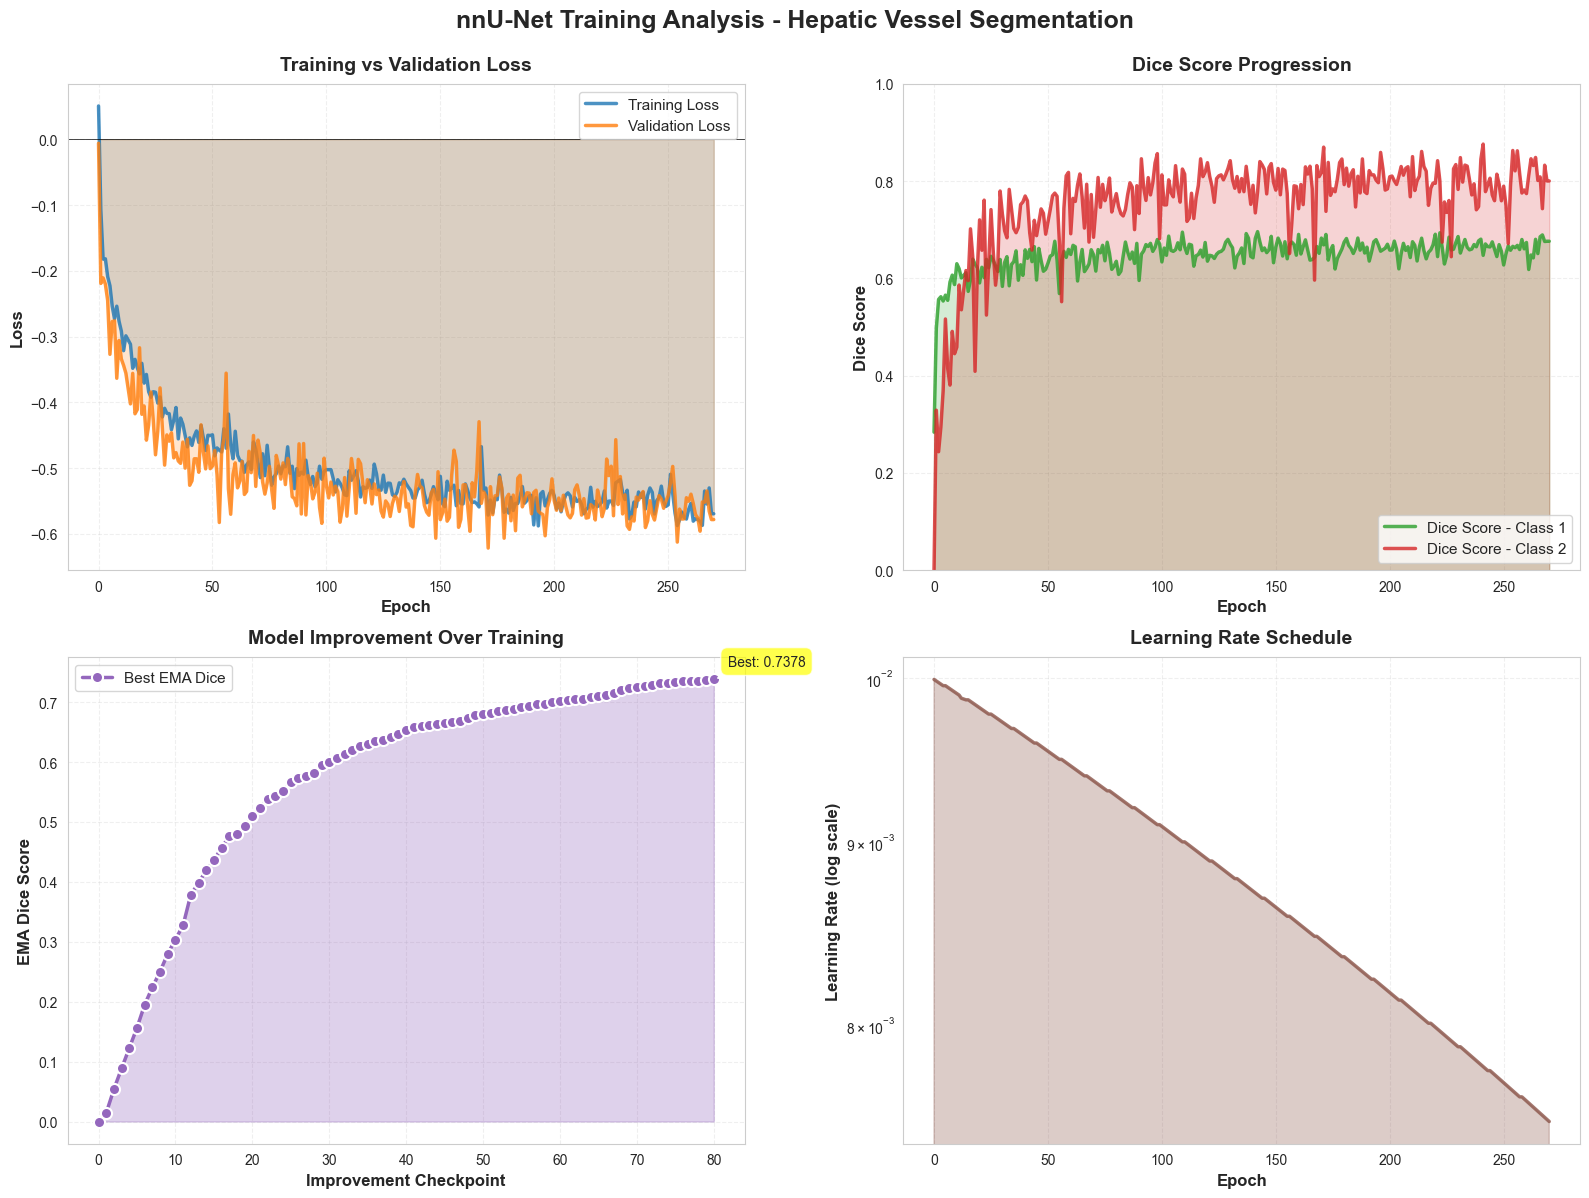

In [7]:
print("📊 Creating comprehensive training analysis plot...")

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('nnU-Net Training Analysis - Hepatic Vessel Segmentation', 
             fontsize=18, fontweight='bold', y=0.995)

# ================================
# Plot 1: Training and Validation Loss
# ================================
ax1 = axes[0, 0]
ax1.plot(df['epoch'], df['train_loss'], label='Training Loss', 
         linewidth=2.5, color='#1f77b4', alpha=0.8)
ax1.plot(df['epoch'], df['val_loss'], label='Validation Loss', 
         linewidth=2.5, color='#ff7f0e', alpha=0.8)
ax1.fill_between(df['epoch'], df['train_loss'], alpha=0.2, color='#1f77b4')
ax1.fill_between(df['epoch'], df['val_loss'], alpha=0.2, color='#ff7f0e')
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training vs Validation Loss', fontsize=14, fontweight='bold', pad=10)
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# ================================
# Plot 2: Dice Scores Over Time
# ================================
ax2 = axes[0, 1]
ax2.plot(df['epoch'], df['dice_1'], label='Dice Score - Class 1', 
         linewidth=2.5, color='#2ca02c', alpha=0.8)
ax2.plot(df['epoch'], df['dice_2'], label='Dice Score - Class 2', 
         linewidth=2.5, color='#d62728', alpha=0.8)
ax2.fill_between(df['epoch'], df['dice_1'], alpha=0.2, color='#2ca02c')
ax2.fill_between(df['epoch'], df['dice_2'], alpha=0.2, color='#d62728')
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Dice Score', fontsize=12, fontweight='bold')
ax2.set_title('Dice Score Progression', fontsize=14, fontweight='bold', pad=10)
ax2.legend(fontsize=11, loc='lower right')
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3, linestyle='--')

# ================================
# Plot 3: Best EMA Dice Progress
# ================================
ax3 = axes[1, 0]
if ema_dice_list:
    improvement_steps = list(range(len(ema_dice_list)))
    ax3.plot(improvement_steps, ema_dice_list, marker='o', linewidth=2.5, 
             markersize=8, color='#9467bd', label='Best EMA Dice', 
             markeredgecolor='white', markeredgewidth=1.5)
    ax3.fill_between(improvement_steps, ema_dice_list, alpha=0.3, color='#9467bd')
    
    # Annotate best score
    best_score = max(ema_dice_list)
    best_idx = ema_dice_list.index(best_score)
    ax3.annotate(f'Best: {best_score:.4f}', 
                xy=(best_idx, best_score), 
                xytext=(10, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
    
ax3.set_xlabel('Improvement Checkpoint', fontsize=12, fontweight='bold')
ax3.set_ylabel('EMA Dice Score', fontsize=12, fontweight='bold')
ax3.set_title('Model Improvement Over Training', fontsize=14, fontweight='bold', pad=10)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')

# ================================
# Plot 4: Learning Rate Schedule
# ================================
ax4 = axes[1, 1]
ax4.plot(df['epoch'], df['learning_rate'], linewidth=2.5, color='#8c564b', alpha=0.8)
ax4.fill_between(df['epoch'], df['learning_rate'], alpha=0.3, color='#8c564b')
ax4.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax4.set_ylabel('Learning Rate (log scale)', fontsize=12, fontweight='bold')
ax4.set_title('Learning Rate Schedule', fontsize=14, fontweight='bold', pad=10)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_yscale('log')

plt.tight_layout()
plt.savefig('comprehensive_training_analysis.png', dpi=300, bbox_inches='tight')
print("✅ Saved: comprehensive_training_analysis.png")
plt.show()

6. Create Smoothed Curves

📊 Creating smoothed curves...
✅ Saved: smoothed_training_curves.png


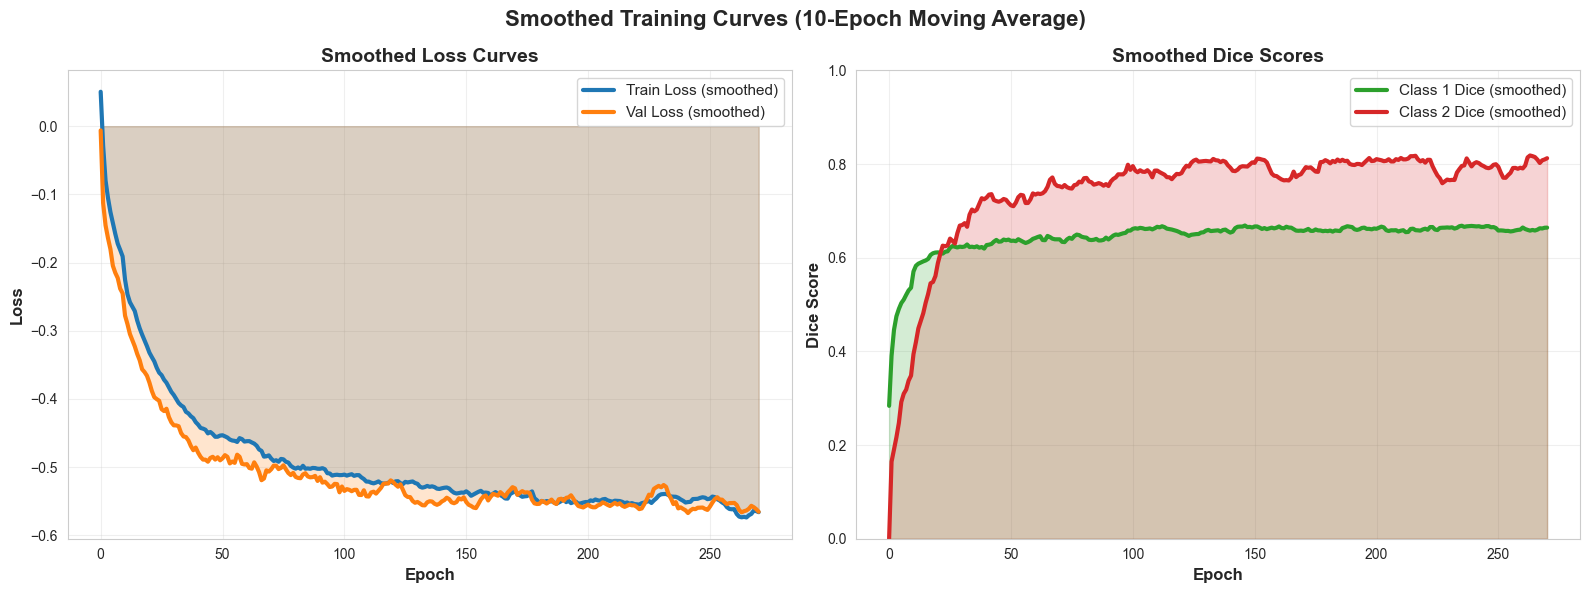

In [8]:
print("📊 Creating smoothed curves...")

# Function for moving average
def moving_average(data, window=10):
    return pd.Series(data).rolling(window=window, min_periods=1).mean()

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Smoothed Training Curves (10-Epoch Moving Average)', 
             fontsize=16, fontweight='bold')

# Smoothed Loss
ax1 = axes[0]
ax1.plot(df['epoch'], moving_average(df['train_loss'], 10), 
         label='Train Loss (smoothed)', linewidth=3, color='#1f77b4')
ax1.plot(df['epoch'], moving_average(df['val_loss'], 10), 
         label='Val Loss (smoothed)', linewidth=3, color='#ff7f0e')
ax1.fill_between(df['epoch'], moving_average(df['train_loss'], 10), 
                  alpha=0.2, color='#1f77b4')
ax1.fill_between(df['epoch'], moving_average(df['val_loss'], 10), 
                  alpha=0.2, color='#ff7f0e')
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Smoothed Loss Curves', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Smoothed Dice
ax2 = axes[1]
ax2.plot(df['epoch'], moving_average(df['dice_1'], 10), 
         label='Class 1 Dice (smoothed)', linewidth=3, color='#2ca02c')
ax2.plot(df['epoch'], moving_average(df['dice_2'], 10), 
         label='Class 2 Dice (smoothed)', linewidth=3, color='#d62728')
ax2.fill_between(df['epoch'], moving_average(df['dice_1'], 10), 
                  alpha=0.2, color='#2ca02c')
ax2.fill_between(df['epoch'], moving_average(df['dice_2'], 10), 
                  alpha=0.2, color='#d62728')
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Dice Score', fontsize=12, fontweight='bold')
ax2.set_title('Smoothed Dice Scores', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('smoothed_training_curves.png', dpi=300, bbox_inches='tight')
print("✅ Saved: smoothed_training_curves.png")
plt.show()

7. Create Summary Report

📋 Creating summary report...


C:\Users\Admin\AppData\Local\Temp\ipykernel_12212\2153260478.py:70: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_12212\2153260478.py:70: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_12212\2153260478.py:70: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_12212\2153260478.py:70: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_12212\2153260478.py:70: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_12212\2153260478.py:70: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) miss

✅ Saved: training_summary_report.png


c:\Users\Admin\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(

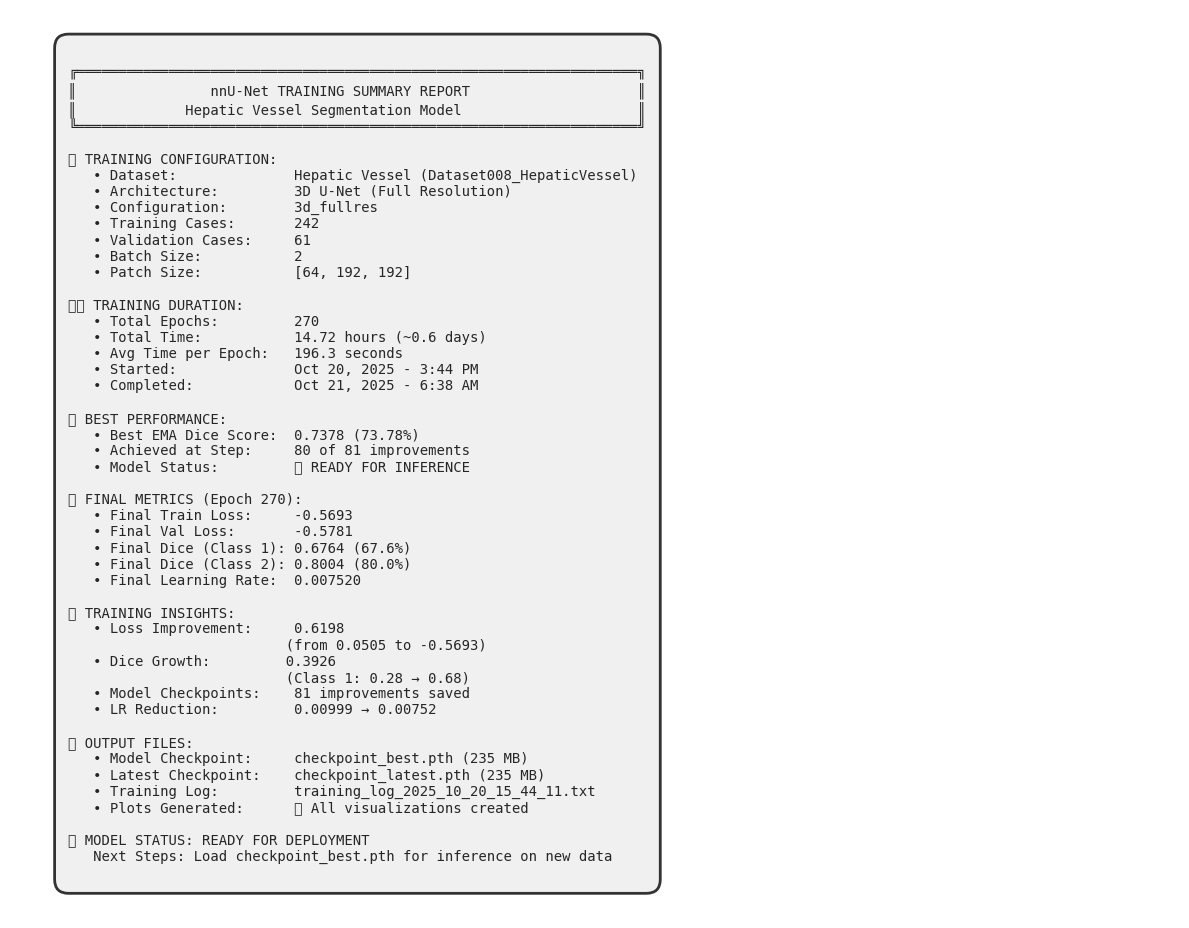

In [9]:
print("📋 Creating summary report...")

# Calculate statistics
total_epochs = df['epoch'].max()
best_ema_dice = max(ema_dice_list) if ema_dice_list else 0
best_checkpoint = ema_dice_list.index(best_ema_dice) if ema_dice_list else 0
total_time_hours = sum(df['epoch_time']) / 3600

# Create text report
fig, ax = plt.subplots(figsize=(12, 10))
ax.axis('off')

summary_text = f"""
╔═══════════════════════════════════════════════════════════════════╗
║                nnU-Net TRAINING SUMMARY REPORT                    ║
║             Hepatic Vessel Segmentation Model                     ║
╚═══════════════════════════════════════════════════════════════════╝

📊 TRAINING CONFIGURATION:
   • Dataset:              Hepatic Vessel (Dataset008_HepaticVessel)
   • Architecture:         3D U-Net (Full Resolution)
   • Configuration:        3d_fullres
   • Training Cases:       242
   • Validation Cases:     61
   • Batch Size:           2
   • Patch Size:           [64, 192, 192]

⏱️ TRAINING DURATION:
   • Total Epochs:         {total_epochs}
   • Total Time:           {total_time_hours:.2f} hours (~{total_time_hours/24:.1f} days)
   • Avg Time per Epoch:   {df['epoch_time'].mean():.1f} seconds
   • Started:              Oct 20, 2025 - 3:44 PM
   • Completed:            Oct 21, 2025 - 6:38 AM

🎯 BEST PERFORMANCE:
   • Best EMA Dice Score:  {best_ema_dice:.4f} ({best_ema_dice*100:.2f}%)
   • Achieved at Step:     {best_checkpoint} of {len(ema_dice_list)} improvements
   • Model Status:         ✅ READY FOR INFERENCE

📈 FINAL METRICS (Epoch {total_epochs}):
   • Final Train Loss:     {df['train_loss'].iloc[-1]:.4f}
   • Final Val Loss:       {df['val_loss'].iloc[-1]:.4f}
   • Final Dice (Class 1): {df['dice_1'].iloc[-1]:.4f} ({df['dice_1'].iloc[-1]*100:.1f}%)
   • Final Dice (Class 2): {df['dice_2'].iloc[-1]:.4f} ({df['dice_2'].iloc[-1]*100:.1f}%)
   • Final Learning Rate:  {df['learning_rate'].iloc[-1]:.6f}

💡 TRAINING INSIGHTS:
   • Loss Improvement:     {df['train_loss'].iloc[0] - df['train_loss'].iloc[-1]:.4f}
                          (from {df['train_loss'].iloc[0]:.4f} to {df['train_loss'].iloc[-1]:.4f})
   • Dice Growth:         {df['dice_1'].iloc[-1] - df['dice_1'].iloc[0]:.4f}
                          (Class 1: {df['dice_1'].iloc[0]:.2f} → {df['dice_1'].iloc[-1]:.2f})
   • Model Checkpoints:    {len(ema_dice_list)} improvements saved
   • LR Reduction:         {df['learning_rate'].iloc[0]:.5f} → {df['learning_rate'].iloc[-1]:.5f}

📁 OUTPUT FILES:
   • Model Checkpoint:     checkpoint_best.pth (235 MB)
   • Latest Checkpoint:    checkpoint_latest.pth (235 MB)
   • Training Log:         training_log_2025_10_20_15_44_11.txt
   • Plots Generated:      ✅ All visualizations created

✅ MODEL STATUS: READY FOR DEPLOYMENT
   Next Steps: Load checkpoint_best.pth for inference on new data
"""

ax.text(0.05, 0.5, summary_text, fontsize=10, family='monospace',
        verticalalignment='center', 
        bbox=dict(boxstyle='round,pad=1', facecolor='#f0f0f0', 
                 edgecolor='#333333', linewidth=2))

plt.tight_layout()
plt.savefig('training_summary_report.png', dpi=300, bbox_inches='tight')
print("✅ Saved: training_summary_report.png")
plt.show()

8. Print Final Summary

In [10]:
print("\n" + "="*70)
print("🎉 ALL PLOTS GENERATED SUCCESSFULLY!")
print("="*70)
print("\n📁 Files saved in current directory:")
print("   1. ✅ comprehensive_training_analysis.png")
print("   2. ✅ smoothed_training_curves.png")
print("   3. ✅ training_summary_report.png")
print(f"\n📊 Training Summary:")
print(f"   • Total Epochs: {df['epoch'].max()}")
print(f"   • Best EMA Dice: {max(ema_dice_list):.4f} ({max(ema_dice_list)*100:.2f}%)")
print(f"   • Final Train Loss: {df['train_loss'].iloc[-1]:.4f}")
print(f"   • Final Val Loss: {df['val_loss'].iloc[-1]:.4f}")
print(f"   • Final Dice (Class 1): {df['dice_1'].iloc[-1]:.4f}")
print(f"   • Final Dice (Class 2): {df['dice_2'].iloc[-1]:.4f}")
print(f"   • Training Duration: ~{sum(df['epoch_time'])/3600:.1f} hours")
print(f"   • Model Improvements: {len(ema_dice_list)} times")
print("\n✅ Your model is ready for inference!")
print("="*70)


🎉 ALL PLOTS GENERATED SUCCESSFULLY!

📁 Files saved in current directory:
   1. ✅ comprehensive_training_analysis.png
   2. ✅ smoothed_training_curves.png
   3. ✅ training_summary_report.png

📊 Training Summary:
   • Total Epochs: 270
   • Best EMA Dice: 0.7378 (73.78%)
   • Final Train Loss: -0.5693
   • Final Val Loss: -0.5781
   • Final Dice (Class 1): 0.6764
   • Final Dice (Class 2): 0.8004
   • Training Duration: ~14.7 hours
   • Model Improvements: 81 times

✅ Your model is ready for inference!
